# Rud Gallium MFA — Notebook 3

Material flow analysis (MFA) of gallium embodied in final LED products, based
on EUROSTAT COMEXT trade data: import/export tables, BAU and LED-adoption
projections, and a cohort-based dynamic stock-flow model.

In [22]:
##### Initial import and setup #####
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import plotly

# Ignore warnings for cleaner output
import warnings

warnings.filterwarnings("ignore", "Workbook contains no default style", UserWarning)

## ETL EUROSTAT data
### Extract: EUROSTAT COMEXT data

In [23]:
# Load data/EUROSTAT_COMEXT.csv into a DataFrame
comext_df = pd.read_csv("data/EUROSTAT_COMEXT.csv")

# Select relevant columns
selected_columns = [
    "reporter",
    "partner",
    "product",
    "PRODUCT",
    "flow",
    "FLOW",
    "indicators",
    "TIME_PERIOD",
    "OBS_VALUE",
]
eurostat_df = comext_df[selected_columns].copy()

### Transform: EUROSTAT COMEXT data

In [24]:
# TEMP: Filter out "product" starting with 87
eurostat_df = eurostat_df[~eurostat_df["product"].astype(str).str.startswith("87")]

# Display unique values for product and corresponding PRODUCT as dictionary
product_dict = dict(zip(eurostat_df["product"], eurostat_df["PRODUCT"]))
# print("Unique products and their corresponding PRODUCT codes:")
# for product, code in product_dict.items():
#     print(f"{product}: {code}")


# Only focusing on "final_LED" products for now, which corresponds to product code 853950
# Categorymapping based on product codes
category_mapping = {
    # 'raw_Ga': 81129289,
    # 'intermediate_LED' : 854140,
    # 'intermediate_IC' : [854231, 854232, 854233, 854239],
    "final_LED": 853950,
}


### Configure product info selection
Select which products are part of the analysis and setup their parameters (lifespan, market share, material intensity etc.)


Primary sources for material intensities, survival curve, lifespan, market share and product code for all products (in order of importance, high to low):
- (Gao et al., 2024)
- (Jia et al., 2022)
- (Løvik et al., 2015)

**Bibliography**:

Gao, Z., Geng, Y., Li, M., Liang, J.-J., & Houssini, K. (2024). Tracking the global anthropogenic gallium cycle during 2000–2020: A trade-linked multiregional material flow analysis. Global Environmental Change, 87, 102859. https://doi.org/10.1016/j.gloenvcha.2024.102859

Jia, H., Zhou, Y., Wang, A., Wang, G., Li, T., Wang, C., Xing, W., Ma, Z., & Li, P. (2022). Evolution of the Anthropogenic Gallium Cycle in China From 2005 to 2020. Frontiers in Energy Research, 10. https://doi.org/10.3389/fenrg.2022.944617

Løvik, A. N., Restrepo, E., & Müller, D. B. (2015). The Global Anthropogenic Gallium System: Determinants of Demand, Supply and Efficiency Improvements. Environmental Science & Technology, 49(9), 5704–5712. https://doi.org/10.1021/acs.est.5b00320


In [25]:
# Create some data structure to hold categorical text, product code, lifespan, and material intensity
product_info = {
    "final_LED": {
        "product": 853950,
        "lifespan_years": 6,  # Example lifespan for final LED products
        "market_share": 1,
        "material_intensity_Ga": 0.000014,
    },
}

### Load: EUROSTAT COMEXT data
Based on product selection

In [26]:
def build_imp_exp_table(df, product_code, partner="EXT_EU27_2020"):
    """Build a yearly import/export/net-flow table (in kg) for a given product code.

    Filters and pivots dataframe.

    Args:
        df: COMEXT-format DataFrame containing at least the columns
            "product", "indicators", "partner", "FLOW", "TIME_PERIOD",
            and "OBS_VALUE".
        product_code: Product code (as used in the "product" column) to
            filter the data on.
        partner: Trade partner code to filter on. Defaults to
            "EXT_EU27_2020" (extra-EU27 trade).

    Returns:
        DataFrame: One row per TIME_PERIOD with columns "TIME_PERIOD",
        "Exports_kg", "Imports_kg", and "Net_Flow_kg" (Imports - Exports).
    """
    indicator = "QUANTITY_IN_100KG"
    scale_to_kg = 100
    # Filter relevant records
    filtered_df = df[
        (df["product"] == product_code)
        & (df["indicators"] == indicator)
        & (df["partner"] == partner)
    ].copy()

    # Convert unit (e.g., 100kg -> kg)
    filtered_df["OBS_VALUE_KG"] = filtered_df["OBS_VALUE"] * scale_to_kg

    # Aggregate by year and flow
    flow_df = filtered_df.groupby(["TIME_PERIOD", "FLOW"], as_index=False)[
        "OBS_VALUE_KG"
    ].sum()

    # Pivot to import/export columns
    pivot_df = flow_df.pivot(
        index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE_KG"
    ).fillna(0)

    # Ensure both columns exist
    for col in ["EXPORT", "IMPORT"]:
        if col not in pivot_df.columns:
            pivot_df[col] = 0

    pivot_df = pivot_df.rename(columns={"EXPORT": "Exports_kg", "IMPORT": "Imports_kg"})
    pivot_df["Net_Flow_kg"] = pivot_df["Imports_kg"] - pivot_df["Exports_kg"]
    pivot_df = pivot_df.reset_index()

    # return filtered_df, flow_df, pivot_df
    return pivot_df


def plot_imp_exp_table(df, display_product_name):
    """Line-plot for inspection of exp_table
    Shows a line for Exports_kg, Imports_kg, and Net_Flow_kg over TIME_PERIOD for a product.

    Args:
        df: DataFrame with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg" (e.g. as returned by
            build_imp_exp_table or translate_to_Ga_MI).
        display_product_name: Display name of the product, used in the plot title.

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    # Plot exports, imports, and net flow over time for final LED products
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Exports_kg",
        marker="o",
        label="Exports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Imports_kg",
        marker="o",
        label="Imports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Net_Flow_kg",
        marker="o",
        label="Net Flow (kg/y)",
    )
    plt.title(f"{display_product_name} - EU\nExports, Imports, and Net Flow Over Time")
    plt.xlabel("Year")
    plt.ylabel("Quantity (kg/y)")
    plt.xticks(
        rotation=45, ticks=df["TIME_PERIOD"].unique()
    )  # Set x ticks format to integer years and rotate
    plt.legend()
    plt.grid()
    plt.show()

## MFA functionality
### Helpers: Products

In [27]:
def translate_to_Ga_MI(df, material_intensity_Ga):
    """Scale an Imports/Exports/Net_Flow (kg) table by a gallium material intensity factor.

    Args:
        df: DataFrame (imp_exp_table) with columns "Imports_kg", "Exports_kg",
            and "Net_Flow_kg" (e.g. as returned by build_imp_exp_table).
        material_intensity_Ga: Mass fraction (kg Ga per kg product) used to
            convert product mass flows into gallium mass flows.

    Returns:
        pd.DataFrame: Copy of df with "Imports_kg", "Exports_kg",
        and "Net_Flow_kg" scaled by material_intensity_Ga (now representing
        gallium mass instead of product mass).
    """
    imp_exp_table_Ga = df.copy()
    imp_exp_table_Ga["Imports_kg"] = df["Imports_kg"] * material_intensity_Ga
    imp_exp_table_Ga["Exports_kg"] = df["Exports_kg"] * material_intensity_Ga
    imp_exp_table_Ga["Net_Flow_kg"] = df["Net_Flow_kg"] * material_intensity_Ga
    return imp_exp_table_Ga


def add_normal_survival_curve_to_all_products(
    product_info, std_dev_fraction_of_mean=0.25
):
    """Attach a normal-distribution survival curve to every product in product_info.

    Sets each product's `survival_curve_parameters` using its `lifespan_years`
    as the mean and `std_dev_fraction_of_mean * lifespan_years` as the std dev.

    Args:
        product_info: Dict mapping product name to a dict of product
            attributes.
        std_dev_fraction_of_mean: Fraction of `lifespan_years` used as the
            standard deviation of the normal survival curve. Defaults to 0.25.

    Returns:
        None: Changes product_info in place by adding a
        "survival_curve_parameters" key (dict with "type", "mean", and
        "std_dev") to each product entry.
    """
    for product in product_info:
        product_info[product]["survival_curve_parameters"] = {
            "type": "normal",
            "mean": product_info[product]["lifespan_years"],
            "std_dev": product_info[product]["lifespan_years"]
            * std_dev_fraction_of_mean,
        }


def add_future_BAU_projection(imp_exp_table, growth_rate=0, end_year=2050):
    """Extend a Net_Flow_kg table to end_year with a constant compound growth rate (business-as-usual).

    Args:
        imp_exp_table: DataFrame (imp_exp_table) with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg". Should be translated to Ga
        growth_rate: Constant year-over-year growth rate applied to the
            last known Net_Flow_kg value. Defaults to 0 (flat projection).
        end_year: Last year (inclusive) to project up to. Defaults to 2050.

    Returns:
        pd.DataFrame: imp_exp_table concatenated with one row per projected
        year from the year after the last observed year through end_year.
        Projected rows have "Exports_kg" and "Imports_kg" set to 0 and
        "Net_Flow_kg" set to the compounded projection.
    """
    # Get the last year in the existing data
    last_year = imp_exp_table["TIME_PERIOD"].max()

    # Create a DataFrame for future years
    future_years = pd.DataFrame(
        {
            "TIME_PERIOD": range(last_year + 1, end_year + 1),
            "Exports_kg": 0.0,
            "Imports_kg": 0.0,
            "Net_Flow_kg": 0.0,
        }
    )

    # Get the last known net flow value
    last_net_flow = imp_exp_table.loc[
        imp_exp_table["TIME_PERIOD"] == last_year, "Net_Flow_kg"
    ].values[0]

    # Project future net flow based on growth rate
    for i in range(len(future_years)):
        future_years.at[i, "Net_Flow_kg"] = last_net_flow * (1 + growth_rate) ** (i + 1)

    # Combine with original table
    combined_table = pd.concat([imp_exp_table, future_years], ignore_index=True)

    return combined_table


# Add BAU projection for LED, that increases from 46.3% in 2021 to 100% in 2030 using an s-curve growth
# Source: https://www.iea.org/energy-system/buildings/lighting#tracking
def add_LED_BAU_projection(
    imp_exp_table,
    start_year=2021,
    saturation_year=2030,
    end_year=2050,
    start_share=0.463,
    end_share=1.0,
):
    """Extend a Net_Flow_kg table to end_year using an s-curve ramp of LED market share.

    Net flow grows from `start_share` to `end_share` between `start_year` and
    `saturation_year` following a smoothstep s-curve, then holds at `end_share`
    until `end_year`.

    Args:
        imp_exp_table: DataFrame with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg" (e.g. as returned by
            build_imp_exp_table or translate_to_Ga_MI).
        start_year: Year at which the LED market share ramp starts (and at
            which `start_share` applies). Defaults to 2021.
        saturation_year: Year at which the LED market share reaches
            `end_share` and the ramp flattens out. Defaults to 2030.
        end_year: Last year (inclusive) to project up to. Defaults to 2050.
        start_share: LED market share at `start_year`, as a fraction.
            Defaults to 0.463.
        end_share: LED market share from `saturation_year` onward, as a
            fraction. Defaults to 1.0.

    Returns:
        pd.DataFrame: imp_exp_table concatenated with one row per projected
        year from the year after the last observed year through end_year.
        Projected rows have "Exports_kg" and "Imports_kg" set to 0 and
        "Net_Flow_kg" scaled by the LED market-share s-curve.
    """
    # Get the last year in the existing data
    last_year = imp_exp_table["TIME_PERIOD"].max()

    # Create a DataFrame for future years
    future_years = pd.DataFrame(
        {
            "TIME_PERIOD": range(last_year + 1, end_year + 1),
            "Exports_kg": 0.0,
            "Imports_kg": 0.0,
            "Net_Flow_kg": 0.0,
        }
    )

    # Get the last known net flow value
    last_net_flow = imp_exp_table.loc[
        imp_exp_table["TIME_PERIOD"] == last_year, "Net_Flow_kg"
    ].values[0]

    # Project future net flow based on s-curve (ease-in-ease-out) growth of LED market share
    for i in range(len(future_years)):
        year = future_years.at[i, "TIME_PERIOD"]
        if year <= saturation_year:
            # Calculate the LED market share for the current year using an s-curve
            t = (year - start_year) / (
                saturation_year - start_year
            )  # Normalize to [0, 1]
            led_share = start_share + (end_share - start_share) * (
                t**2 * (3 - 2 * t)
            )  # S-curve formula
            future_years.at[i, "Net_Flow_kg"] = last_net_flow + (
                last_net_flow * (led_share - start_share)
            )
        else:
            future_years.at[i, "Net_Flow_kg"] = last_net_flow + (
                last_net_flow * (end_share - start_share)
            )

    # Combine with original table
    combined_table = pd.concat([imp_exp_table, future_years], ignore_index=True)

    return combined_table


### Functions: Flow driven model

In [28]:
def calculate_flow_driven_MFA(
    year_inflow_data, show_output=True, survival_curve_parameters=None
):
    """Run a flow-driven, cohort-based dynamic material flow analysis (MFA).

    Given yearly inflows (TIME_PERIOD, Net_Flow_kg) and a survival curve
    (fixed_lifetime, weibull, normal, leaching, uniform, or lognormal),
    builds per-cohort survival matrices and derives stocks, outflows, and
    stock changes via mass balance. Optionally plots the survival curve,
    survival/cohort matrices, and resulting flows/stocks.

    Args:
        year_inflow_data: DataFrame with at least the columns "TIME_PERIOD"
            and "Net_Flow_kg", one row per year, used as the system inflows.
        show_output: Whether to display intermediate matrices and plots
            (survival curve, survival/cohort heatmaps, flows, stocks).
            Defaults to True.
        survival_curve_parameters: Dict describing the survival curve. Must
            contain a "type" key, one of "fixed_lifetime" (requires
            "lifetime"), "weibull" (requires "shape", "location", "scale"),
            "normal" (requires "mean", "std_dev"), "leaching" (requires
            "depreciation_rate"), "uniform" (requires "uniform_removal"), or
            "lognormal" (requires "shape", "location", "scale").

    Returns:
        pd.DataFrame: Indexed by year, with columns "stocks [kg]",
        "inflows [kg/year]", "outflows [kg/year]", and
        "stock_changes [kg/year]".

    Raises:
        ValueError: If year_inflow_data is missing the required columns, or
            if survival_curve_parameters["type"] is not a recognized type.
    """

    # %% 2. input data into the model
    # Check columns of the input data
    expected_columns = {"TIME_PERIOD", "Net_Flow_kg"}
    if not expected_columns.issubset(year_inflow_data.columns):
        raise ValueError(
            f"Input data must contain the following columns: {expected_columns}"
        )

    # %%% 2.1 inflows - Keep only "TIME_SERIES" and "Net_Flow_kg"
    input_data = year_inflow_data[["TIME_PERIOD", "Net_Flow_kg"]].copy()
    input_data = input_data.rename(
        columns={"TIME_PERIOD": "year", "Net_Flow_kg": "inflows"}
    )
    input_data["year"] = input_data["year"].astype(int)
    input_data = input_data.set_index("year")["inflows"]

    # dictionary for units
    input_data_units = {"inflows": "kg/year"}

    # %%% 2.2 survival curve
    # the ages of a cohort start at zero when the cohort was an inflow.
    # The maximum age a cohort can reach in the MFA model is equal to the length of the input data
    ages = range(0, len(input_data))

    # Fixed lifetime / the delay model
    if survival_curve_parameters["type"] == "fixed_lifetime":
        lifetime = survival_curve_parameters["lifetime"]
        survival_curve = np.zeros_like(ages)
        survival_curve[0:lifetime] = 1
    # Weibull distribution survival curve
    elif survival_curve_parameters["type"] == "weibull":
        shape = survival_curve_parameters["shape"]
        location = survival_curve_parameters["location"]
        scale = survival_curve_parameters["scale"]
        survival_curve = scipy.stats.weibull_min.sf(
            ages, c=shape, loc=location, scale=scale
        )
    # Normal distribution survival curve
    elif survival_curve_parameters["type"] == "normal":
        mean = survival_curve_parameters["mean"]
        std_dev = survival_curve_parameters["std_dev"]
        survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)
    # Geometric distribution survival curve / the leaching model
    elif survival_curve_parameters["type"] == "leaching":
        depreciation_rate = survival_curve_parameters["depreciation_rate"]
        survival_curve = scipy.stats.geom.sf(ages, depreciation_rate)
    # Uniform distribution survival curve / slope survival curve
    elif survival_curve_parameters["type"] == "uniform":
        uniform_removal = survival_curve_parameters["uniform_removal"]
        survival_curve = scipy.stats.uniform.sf(ages, loc=0, scale=1 / uniform_removal)
    # Log-normal distribution survival curve
    elif survival_curve_parameters["type"] == "lognormal":
        shape = survival_curve_parameters["shape"]  # Original values = 2
        location = survival_curve_parameters["location"]  # Original values = 0
        scale = survival_curve_parameters["scale"]  # Original values = 40
        survival_curve = scipy.stats.lognorm.sf(
            ages, s=shape, loc=location, scale=scale
        )
    else:
        raise ValueError("Invalid survival curve type.")

    # visualize the survival curve
    if show_output:
        plt.plot(ages, survival_curve)
        plt.xlabel("Age")
        plt.ylabel("Survival rate")
        plt.title("Survival curve")
        plt.show()

    # %% 3. Set up the MFA system

    units = {"time_interval": "year", "flows": "kg/year", "stocks": "kg"}

    timeframes = cohorts = (
        input_data.index
    )  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

    cohorts_end = (
        cohorts[-1] + 1
    )  # because of exclusive slicing in python, an extra time interval is required

    mfa_system = pd.DataFrame(
        index=timeframes, columns=["stocks", "inflows", "outflows", "stock_changes"]
    )

    mfa_system["inflows"] = input_data

    # %% 4. Create the survival curves matrix

    # create an initial survival curves matrix filled with zeros'
    survival_curves_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # and populate that matrix, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, fill a shifted survival curve (cut at its end) into the next column of the survival curves matrix, from the diagonal downwards. Leave the upper part with zeros.
        survival_curves_matrix.loc[cohort:, cohort] = survival_curve[
            0 : cohorts_end - cohort
        ]

    if show_output:
        display(round(survival_curves_matrix, 3))

        # Plot the survival curves matrix as a heatmap
        sns.heatmap(survival_curves_matrix, cbar_kws={"label": "Survival Probability"})
        plt.show()

    # %% 5. Create the cohorts survival matrix

    # initialize the cohort_survival_matrix filled with zeros
    cohorts_survival_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # And populate it, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, scale the shifted survival curve with the inflow of the time-th timeframe.
        cohorts_survival_matrix.loc[:, cohort] = (
            survival_curves_matrix.loc[:, cohort] * mfa_system["inflows"].loc[cohort]
        )

    if show_output:
        # and visualize the cohort_survival_matrix matrix with a heatmap
        sns.heatmap(cohorts_survival_matrix, annot=False)
        plt.show()

    # %% 6. Calculate the MFA system
    # %%% 6.1 Calculate stocks

    # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
    mfa_system["stocks"] = cohorts_survival_matrix.sum(axis="columns")

    # %%% 6.2 Calculate stock changes (nas)
    # stock_changes is the difference between two timeframes.
    # prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
    # without it, np.diff calculates the difference between current timeframe and next timeframe.
    mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)

    # %%% 6.3 Calculate outflows
    # using mass balance
    mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

    # %% 7. View the full MFA system
    # add the units of measurements
    mfa_system_with_units = mfa_system.rename(
        columns={
            "stocks": "stocks [" + units["stocks"] + "]",
            "inflows": "inflows [" + units["flows"] + "]",
            "outflows": "outflows [" + units["flows"] + "]",
            "stock_changes": "stock_changes [" + units["flows"] + "]",
        }
    )

    # %%% 7.1 Plot results
    if show_output:
        # plot flows
        mfa_system_with_units[
            ["inflows [kg/year]", "outflows [kg/year]", "stock_changes [kg/year]"]
        ].plot(ylabel="flows [kg/year]", color=["#2A8596", "#D19F37", "#8E795E"])
        plt.show()

        # plot stocks
        mfa_system_with_units["stocks [kg]"].plot(
            kind="area", stacked=True, ylabel="stocks [kg]", color="#DC322F"
        )
        plt.show()

        # plot stocks composition by cohorts
        cohorts_survival_matrix.plot(
            kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]"
        )
        plt.show()

    return mfa_system_with_units


### Functions: Life cycle model

In [29]:
# Multi index dictionary => Lifecycle stage number and name mapping
# ! Setup with dummy numbers for now
# TODO Change to actual numbers
lifecycle_stages_names = {
    1: {
        "name": "mining",
        "TC_output": {
            2: 0.5,
        },
    },
    2: {
        "name": "smelting",
        "TC_output": {
            3: 0.5,
        },
    },
    3: {
        "name": "Refining",
        "TC_output": {
            4: 0.5,
        },
    },
    4: {
        "name": "Manufacturing",
        "TC_output": {
            5: 0.5,
        },
    },
    5: {
        "name": "Use",
        "TC_output": {
            6: 1,
        },
    },
    6: {
        "name": "End-of-Life",
    },
}
use_phase_stage_number = 5


def _build_TC_graph(lifecycle_stages_names):
    """Simplifying the lifecycle stages dictionary by extracting TC_output entries.
    Builds a dict mapping each stage to its TC_output dict (or an empty dict if none).
    This actually creates a sort of directed graph, which can be used for searching later.

    Args:
        lifecycle_stages_names: Dict mapping stage number to a dict with a
            "name" and an optional "TC_output" dict ({target_stage: tc}).

    Returns:
        Dict[int, Dict[int, float]]: Dictionary mapping each stage to its
        TC_output targets and their corresponding transfer coefficients.
    """
    return {
        stage: dict(info.get("TC_output", {}))
        for stage, info in lifecycle_stages_names.items()
    }


def _plot_TC_graph(graph):
    """Plot the TC_output graph using matplotlib.

    Args:
        graph: Dict mapping each stage to its TC_output targets and their
            corresponding transfer coefficients.

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    import networkx as nx

    G = nx.DiGraph()
    for stage, targets in graph.items():
        for target, tc in targets.items():
            G.add_edge(stage, target, weight=tc)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("TC_output Graph")
    plt.show()


def _is_reachable(graph, start_stage, goal_stage):
    """Whether goal stage is reachable from start stage by following TC_output edges forward.

    Using graph search method = depth-first search (DFS).
    This is a standard search algorithm, see https://en.wikipedia.org/wiki/Depth-first_search."""
    visited_stages = {start_stage}  # Visited stages
    explore_queue = [start_stage]  # Queue of stages to explore next
    while explore_queue:
        stage = explore_queue.pop()  # Get the next stage to explore
        if stage == goal_stage:  # If we reached the goal stage, return True
            return True
        for target in graph.get(
            stage, {}
        ):  # Explore each TC_output target of the current stage
            if target not in visited_stages:  # If not yet visited
                visited_stages.add(target)  # Mark as visited
                explore_queue.append(target)  # Add to queue for further exploration
    return False  # If we empty the queue without returning True, then the goal stage is not reachable


def _topological_order(graph, stages):
    """Order stages so every predecessor (within `stages`) comes before its successors.
    Currently not needed as there is only one stage after Use.
    But if there were more stages after Use, this is necessary
    to make sure that the stages' inflows are calculated in
    the right order.

    Using graph sorting method = Kahn's algorithm.
    This is a standard algorithm, see https://en.wikipedia.org/wiki/Topological_sorting"""
    remaining_stages = set(stages)
    ordered = []
    while remaining_stages:
        # Find all stages with no incoming edges from other remaining stages
        ready_stages = [
            stage
            for stage in remaining_stages
            if not any(
                stage in graph.get(other_stage, {})
                for other_stage in remaining_stages
                if other_stage != stage
            )
        ]
        # If there are non, then there is a cycle (circular dependency)
        if not ready_stages:
            raise ValueError("Cycle detected in TC_output graph; cannot order stages.")
        # Add the ready stages to the ordered list
        ordered.extend(sorted(ready_stages))
        # Remove the ready stages from the remaining stages before the next iteration
        remaining_stages -= set(ready_stages)
    return ordered


def calculate_lifecycle_flows(
    mfa_system,
    lifecycle_stages_names,
    use_phase_stage_number=use_phase_stage_number,
    detailed_output=False,
):
    """Propagate the Use-phase inflow/outflow through every other lifecycle stage.

    Process:

    1. Setup
    2. Calculate upstream of use stage
    3. Calculate downstream of use stage
    4. Save the results (long-format table)

       - Append inflows
       - Append outflows
       - Append and calculate outflow_product
       - Append and calculate outflow_waste

    Args:
        mfa_system: DataFrame returned by calculate_flow_driven_MFA
        lifecycle_stages_names: Dict with lifecycle information
        use_phase_stage_number: Stage number corresponding to the Use phase
        detailed_output: Plot for debugging

    Returns:
        pd.DataFrame: Long format. One row per (year, stage,flow_type),
        columns
        - "year"
        - "stage_number"
        - "stage_name"
        - "flow_type" ("inflow", "outflow", "outflow_product", or "outflow_waste")
        - "target_stage_number"
        - "target_stage_name"
        - "value_kg"

    Note:
        "outflow_product" => Specific to target stage
        "outflow" => Per stage total => Sum of "outflow_product" and "outflow_waste" rows
    """
    ##############################################################################
    ### 1 ### Setup
    ### 1.1 ### Build and plot TC_output graph
    graph = _build_TC_graph(lifecycle_stages_names)
    if (
        detailed_output
    ):  # If detailed_output is True, plot the TC graph for visualization
        _plot_TC_graph(graph)

    ### 1.2 ### Define upstream and downstream stages for clarity
    all_stages = sorted(
        lifecycle_stages_names
    )  # Make sure stages are processed in a consistent order
    upstream_stages = [s for s in all_stages if s < use_phase_stage_number]
    downstream_stages = [s for s in all_stages if s > use_phase_stage_number]

    ### 1.3 ### Placeholder for inflow and outflow series for every stage, to be filled in step by step.
    inflow = {}
    outflow = {}

    ### 1.4 ### Step 1: Get inflow and outflow for the Use stage.
    inflow[use_phase_stage_number] = mfa_system["inflows [kg/year]"]
    outflow[use_phase_stage_number] = mfa_system["outflows [kg/year]"]

    ##############################################################################
    ### 2. ### Calculate upstream of use stage, going backwards from Use to mining.
    for stage in sorted(upstream_stages, reverse=True):
        # Find the single TC_output edge of `stage` thateventually leads to use stage
        path_of_stages_towards_use = [
            (target_stage, tc)
            for target_stage, tc in graph[stage].items()
            if _is_reachable(graph, target_stage, use_phase_stage_number)
        ]
        if len(path_of_stages_towards_use) != 1:
            raise ValueError(
                f"Stage {stage} must have exactly one TC_output edge leading "
                f"to the Use stage ({use_phase_stage_number}); found "
                f"{len(path_of_stages_towards_use)}."
            )
        next_stage, tc = path_of_stages_towards_use[0]
        # output_to_target = inflow[stage] * tc = inflow[next_stage], so:
        inflow[stage] = inflow[next_stage] / tc
        outflow[stage] = inflow[stage]  # Assumed: no stock => outflow equals inflow

    ##############################################################################
    ### 3. ### Calculate downstream of use stage, going forwards from Use to End-of-Life.
    for stage in _topological_order(
        graph, downstream_stages
    ):  # For each stage downstream of Use, in topological order
        # A stage's inflow is whatever its predecessors send it as product.
        # graph.get(predecessor, {}) => Returns the TC_output dict for predecessor
        # Check if the current stage is a target of that predecessor's TC_output
        predecessors = [
            predecessor
            for predecessor in outflow
            if stage in graph.get(predecessor, {})
        ]
        inflow[stage] = sum(
            outflow[p] * graph[p][stage] for p in predecessors
        )  # Sum of all predecessors' outflow * TC_output to this stage
        # graph[p][stage] => TC_output fraction from predecessor p to current stage
        outflow[stage] = inflow[stage]  # Assumed: no stock => outflow equals inflow

    ##############################################################################
    ### 4. ### Save the results
    rows = []
    for stage in all_stages:
        # Define for each stage
        stage_name = lifecycle_stages_names[stage]["name"]
        stage_inflow = inflow[stage]
        stage_outflow = outflow[stage]

        ### 4.1 ### Append inflows
        for year in stage_inflow.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "inflow",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": stage_inflow.loc[year],
                }
            )

        ### 4.2 ### Append outflows
        for year in stage_outflow.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "outflow",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": stage_outflow.loc[year],
                }
            )

        ### 4.3 ### Append and calculate outflow_product rows
        outflow_product_total = pd.Series(0.0, index=stage_outflow.index)
        for target, tc in graph.get(
            stage, {}
        ).items():  # For each target stage of the current stage's TC_output
            # Define for each target stage
            target_name = lifecycle_stages_names[target]["name"]
            outflow_product_series = stage_outflow * tc
            outflow_product_total = outflow_product_total + outflow_product_series

            # Append outflow_product rows
            for year in outflow_product_series.index:
                rows.append(
                    {
                        "year": year,
                        "stage_number": stage,
                        "stage_name": stage_name,
                        "flow_type": "outflow_product",
                        "target_stage_number": target,
                        "target_stage_name": target_name,
                        "value_kg": outflow_product_series.loc[year],
                    }
                )

        ### 4.4 ### Append and calculate outflow_waste rows
        outflow_waste_series = (
            stage_outflow - outflow_product_total
        )  # Assumed: outflow_waste = outflow - sum(outflow_product)
        for year in outflow_waste_series.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "outflow_waste",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": outflow_waste_series.loc[year],
                }
            )

    return pd.DataFrame(rows)


def plot_sankey_lifecycle_flows(lifecycle_flows_df, year, plot_waste_per_stage=False):
    """Plot the lifecycle flows for a specific year.
    Using a sankey diagram to visualize the flows between lifecycle stages.

    Process:
    1. Extract the data for the specified year
    2. Prepare stage data for the sankey diagram
    3. Prepare the links for the sankey diagram
    4. Create the sankey diagram using plotly

    Args:
        lifecycle_flows_df: Long-format DataFrame as returned by
            calculate_lifecycle_flows (one row per year/stage/flow_type).
        year: Year to plot.
        plot_waste_per_stage: If True, create a separate waste node for
            each stage instead of a single shared "Waste" node.

    Returns:
        None: Displays the plot via plotly; does not return a value.
    """
    import plotly.graph_objects as go

    ### 1. ### Extract the data for the specified year
    # Extract the data for the specified year
    year_df = lifecycle_flows_df[lifecycle_flows_df["year"] == year]

    ### 2. ### Prepare stage data for the sankey diagram
    # Create list of stages, their indices, and labels for the sankey diagram
    # Add Waste node as well
    stages = (
        year_df[["stage_number", "stage_name"]]
        .drop_duplicates()
        .sort_values("stage_number")
    )
    stage_to_index = {
        stage_number: i for i, stage_number in enumerate(stages["stage_number"])
    }
    node_x = node_y = None

    ### 2.1 ### If plotting waste per stage, create separate waste nodes for each stage
    if plot_waste_per_stage:
        # Create labels => Append "Waste (stage_name)" for each stage
        labels = list(stages["stage_name"]) + [
            f"Waste ({name})" for name in stages["stage_name"]
        ]
        # Create index
        waste_index = {
            stage_number: len(stages) + i
            for i, stage_number in enumerate(stages["stage_number"])
        }

        # Define position (x) of each stage node, evenly spaced by stage number.
        n_stages = len(stages)
        stage_x = {
            stage_number: i / (n_stages - 1) if n_stages > 1 else 0.5
            for i, stage_number in enumerate(stages["stage_number"])
        }
        # Define positions and waste positions (as the next stage position)
        node_x = [stage_x[s] for s in stages["stage_number"]] + [
            stage_x.get(s + 1, stage_x[s]) for s in stages["stage_number"]
        ]
        node_y = [0.5] * (2 * n_stages)
    else:
        labels = list(stages["stage_name"]) + ["Waste"]
        waste_index = len(labels) - 1

    ### 3. ### Prepare the links for the sankey diagram
    # Links between stages: the outflow_product rows already carry the
    # source stage, target stage, and flow value needed for each link.
    # Filter for outflow_product rows with positive values to avoid zero-value links.
    product_flows = year_df[
        (year_df["flow_type"] == "outflow_product") & (year_df["value_kg"] > 0)
    ]
    sources = [stage_to_index[s] for s in product_flows["stage_number"]]
    targets = [stage_to_index[t] for t in product_flows["target_stage_number"]]
    values = list(product_flows["value_kg"])

    # Create waste flow links
    waste_flows = year_df[
        (year_df["flow_type"] == "outflow_waste") & (year_df["value_kg"] > 0)
    ]
    sources += [stage_to_index[s] for s in waste_flows["stage_number"]]
    if plot_waste_per_stage:
        targets += [waste_index[s] for s in waste_flows["stage_number"]]
    else:
        targets += [waste_index] * len(waste_flows)
    values += list(waste_flows["value_kg"])

    ### 4. ### Create the sankey diagram using plotly
    fig = go.Figure(
        go.Sankey(
            arrangement="snap",
            node=dict(
                label=labels,
                pad=20,
                thickness=20,
                **({"x": node_x, "y": node_y} if node_x is not None else {}),
            ),
            link=dict(source=sources, target=targets, value=values),
        )
    )
    fig.update_layout(
        title_text=f"Lifecycle Flows Sankey Diagram for {year}", font_size=12
    )
    fig.show()


def plot_lifecycle_flows_barplot(plot_data_year, year=None):
    """Plot a barplot of lifecycle flows for a specific year.

    Args:
        plot_data_year: mfa_system_with_lifecycle_flows filtered for a specific year, containing

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=plot_data_year,
        x="stage_name",
        y="value_kg",
        hue="flow_type",
        palette={
            "inflow": "#2A8596",
            "outflow": "#D19F37",
            "outflow_product": "#8E795E",
            "outflow_waste": "#DC322F",
        },
    )
    plt.title(f"Lifecycle Flows for Final LED Products in {year}")
    plt.xlabel("Lifecycle Stage")
    plt.ylabel("Flow (kg/year)")
    plt.xticks(rotation=45)
    plt.legend(title="Flow Type")
    plt.grid(axis="y")
    plt.show()


## Main model run
Running the actual model, calling helper and model functions

,stocks [kg],inflows [kg/year],outflows [kg/year],stock_changes [kg/year]
year,,,,
2017,616.285485,616.305004,0.019519,6.162855e+02
2018,1370.147170,754.130482,0.268797,7.538617e+02
2019,2146.068555,778.341970,2.420585,7.759214e+02
2020,2868.161269,736.650726,14.558012,7.220927e+02
2021,3633.450882,824.716732,59.427119,7.652896e+02
2022,4304.742266,839.904417,168.613032,6.712914e+02
2023,4840.792261,880.607412,344.557417,5.360500e+02
2024,5246.331031,939.535628,533.996858,4.055388e+02
2025,5582.472813,1009.398978,673.257196,3.361418e+02


,year,stage_number,stage_name,flow_type,target_stage_number,target_stage_name,value_kg
0,2017,1,mining,inflow,NaN,NaN,9860.880064
1,2018,1,mining,inflow,NaN,NaN,12066.087712
2,2019,1,mining,inflow,NaN,NaN,12453.471520
3,2020,1,mining,inflow,NaN,NaN,11786.411616
4,2021,1,mining,inflow,NaN,NaN,13195.467712
...,...,...,...,...,...,...,...
777,2046,6,End-of-Life,outflow_waste,NaN,NaN,1267.589617
778,2047,6,End-of-Life,outflow_waste,NaN,NaN,1267.589617
779,2048,6,End-of-Life,outflow_waste,NaN,NaN,1267.589617
780,2049,6,End-of-Life,outflow_waste,NaN,NaN,1267.589617


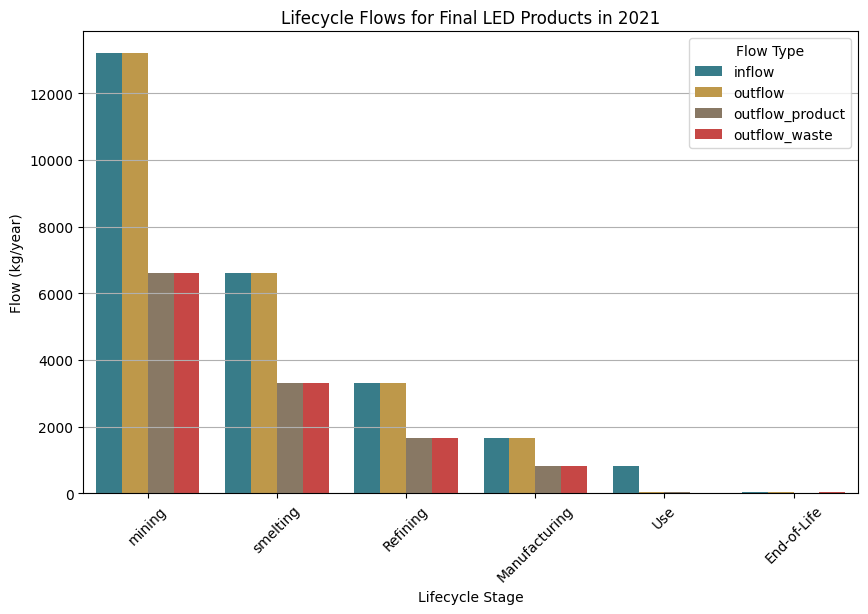

In [30]:
add_normal_survival_curve_to_all_products(product_info)
final_LED_imp_exp_table = build_imp_exp_table(
    eurostat_df, product_info["final_LED"]["product"]
)
final_LED_Ga_imp_exp_table = translate_to_Ga_MI(
    final_LED_imp_exp_table, product_info["final_LED"]["material_intensity_Ga"]
)
# plot_imp_exp_table(final_LED_imp_exp_table, "Final LED Products")
# final_LED_Ga_imp_exp_table_with_projection = add_future_BAU_projection(final_LED_Ga_imp_exp_table, growth_rate=0, end_year=2050)
final_LED_Ga_imp_exp_table_with_projection = add_LED_BAU_projection(
    final_LED_Ga_imp_exp_table
)
# plot_imp_exp_table(
#     final_LED_Ga_imp_exp_table_with_projection, "Final LED Products with BAU Projection"
# )
mfa_system = calculate_flow_driven_MFA(
    final_LED_Ga_imp_exp_table_with_projection,
    show_output=False,
    survival_curve_parameters=product_info["final_LED"]["survival_curve_parameters"],
)
display(mfa_system)
mfa_system_with_lifecycle_flows = calculate_lifecycle_flows(
    mfa_system, lifecycle_stages_names
)
display(mfa_system_with_lifecycle_flows)

# Plot for the year of 2021, showing the flow splits between lifecycle stages
plot_lifecycle_flows_barplot(
    mfa_system_with_lifecycle_flows[mfa_system_with_lifecycle_flows["year"] == 2021],
    year=2021,
)


plot_sankey_lifecycle_flows(
    mfa_system_with_lifecycle_flows, year=2021, plot_waste_per_stage=True
)

## Exploration

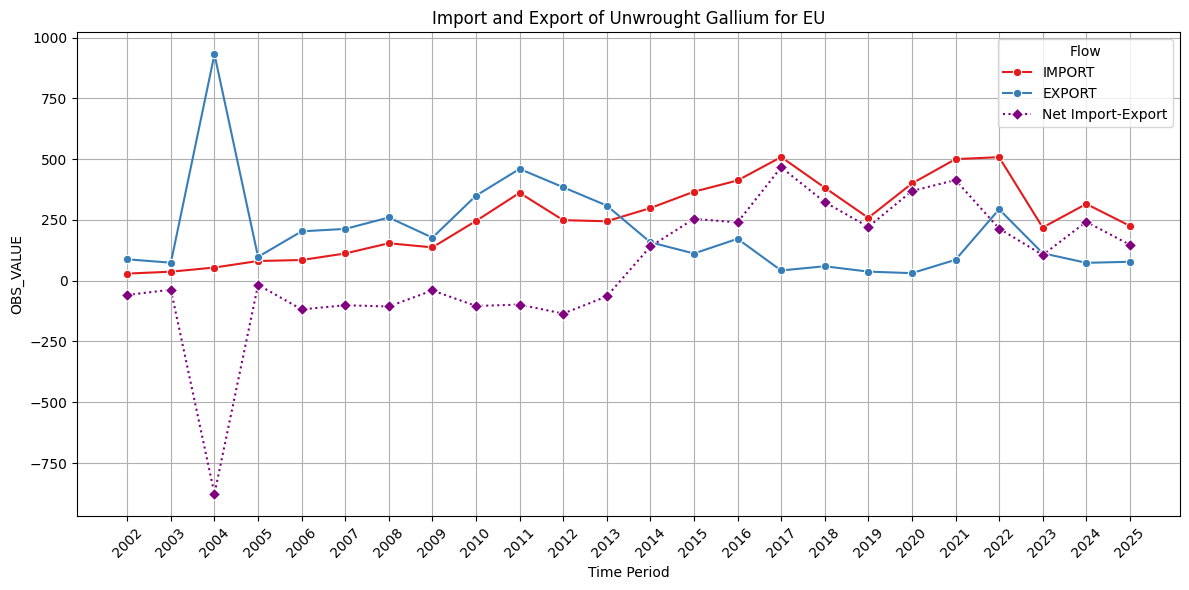

In [31]:
# Plot product "81129289" and indicators "QUANTITY_IN_100KG" with "TIME_PERIOD" on x-axis and "OBS_VALUE" on y-axis, colored by "flow"
# Plot two seperate for partner = "EXT_EU27_2020" and partner = "INT_EU27_2020" => With different legends and colors and markers
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=eurostat_df[
        (eurostat_df["product"] == 81129289)
        & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
        & (eurostat_df["partner"] == "EXT_EU27_2020")
    ],
    x="TIME_PERIOD",
    y="OBS_VALUE",
    hue="FLOW",
    marker="o",
    linestyle="-",
    palette="Set1",
)
# sns.lineplot(data=eurostat_df[(eurostat_df["product"] == 81129289) & (eurostat_df["indicators"] == "QUANTITY_IN_100KG") & (eurostat_df["partner"] == "INT_EU27_2020")],
#              x="TIME_PERIOD", y="OBS_VALUE", hue="FLOW", marker="s", linestyle="--", palette="Set2")
# Calculate and Plot the difference between FLOW = "IMPORT" and FLOW = "EXPORT" for partner = "EXT_EU27_2020"
net_import_export = eurostat_df[
    (eurostat_df["product"] == 81129289)
    & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
    & (eurostat_df["partner"] == "EXT_EU27_2020")
].pivot(index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE")
net_import_export["NET_IMPORT_EXPORT"] = (
    net_import_export["IMPORT"] - net_import_export["EXPORT"]
)
sns.lineplot(
    data=net_import_export,
    x=net_import_export.index,
    y="NET_IMPORT_EXPORT",
    marker="D",
    linestyle=":",
    color="purple",
    label="Net Import-Export",
)
plt.title("Import and Export of Unwrought Gallium for EU")
plt.xlabel("Time Period")
plt.ylabel("OBS_VALUE")
plt.legend(title="Flow")
plt.xticks(rotation=45, ticks=net_import_export.index)
plt.tight_layout()
plt.grid()
plt.show()